# Fetch planets' positions relative to ESMUC

In [6]:
!pip3 install ephem


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [7]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

## Get data

In [16]:
import ephem

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]

''' TODO: ACTUALITZAR AMB LES DADES QUE USARÉ
valsTemplate = {
    'ra': '', 
    'dec': '', 
    'mag': '', 
    'size': '', 
    'separation': ''
}
'''


measurings = dict.fromkeys((planet.name for planet in planets), {}) # Initialize dictionary

# Set up observing point
observer = ephem.Observer()
observer.name = "ESMUC"
observer.lat = '41.39858935189999'
observer.lon = '2.1853450576007365'
observer.elevation = 18  # meters
observer.pressure = 0


startingDate = ephem.Date('2016/06/17 00:00')
observer.date = startingDate - 2*ephem.hour # ephem works with UTC. This accounts for the timezone

rangDies = 1  # days that the simulation will run
stepHores = 1 # how many hours are stepped
resolucio = 23 # bigger resolution = more results
resolucio = 24 - resolucio
print(int(rangDies * (24/resolucio)))

for i in range(int(rangDies * (24/resolucio))):
    for j, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({
            str(observer.date): {
                'ra': planet.ra, 
                'dec': planet.dec, 
                'mag': planet.mag, 
                'size': planet.size, 
                'separation': ephem.separation(observer, planet), 
                'alt': planet.alt, 
                'az': planet.az
                }
            })
            
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}

        # print('%s measured from %s:' % (planet.name, observer.name))
        # print('%s, %s. Magnitude: %s, Size: %s' % (planet.ra, planet.dec, planet.mag, planet.size)) # Right Ascension, Declination (Apparent Topocentric Position, aka des del punt d'observació), magnitude
        # print(ephem.separation(observer, planet))
    observer.date += stepHores * ephem.hour

# pretty((measurings))


24


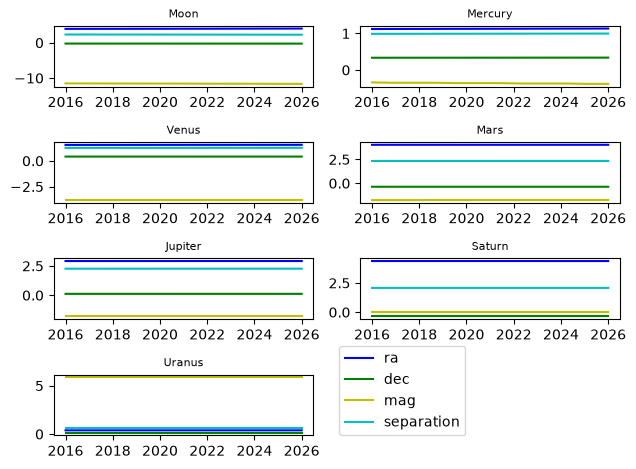

<class 'dict'>


In [9]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2016, 2026, int(rangDies * (24/resolucio))) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'ra': {}, 'dec': {}, 'mag': {}, 'size': {}, 'separation': {}}

    for i in range(len(measurings[planet.name])):
        values["ra"][i] = list(measurings[planet.name].values())[i]["ra"]
        values["dec"][i] = list(measurings[planet.name].values())[i]["dec"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["ra"].values(), 'b', label="ra")
    ax.plot(xAxis, values["dec"].values(), 'g', label="dec")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    # ax.plot(xAxis, values["size"].values(), 'r', label="size")
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

print(type(planetsArray))

## Get planets within viewing scope

Good tools to check if calculations are correct: https://stellarium-web.org/, https://heavens-above.com/

In [68]:
# Using azalts

viewing_angle = ephem.degrees("20:00:00.0") # Minimum azimuth to consider a planet visible (higher az = higher in the sky)

visiblePlanets = {}

for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}

    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]

        az = thisPlanet['az']
        alt = thisPlanet['alt']

        if(alt > viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {'ra' : thisPlanet['ra'], 'dec': thisPlanet['dec'], 'separation': thisPlanet['separation'], 'mag': planet.mag, 'size': planet.size, 'az': az, 'alt': alt, 'time': time.split(" ")[1]}

    visiblePlanets[time] = {**visiblePlanetsAtThisTime}

pretty(visiblePlanets)


2016/6/16 22:00:00
	Moon
		ra
			14:59:21.45
		dec
			-13:14:59.1
		separation
			133:31:00.6
		mag
			-11.79
		size
			1799.53173828125
		az
			195:15:25.5
		alt
			34:03:31.8
		time
			22:00:00
	Mars
		ra
			15:25:03.62
		dec
			-21:01:46.8
		separation
			134:06:02.0
		mag
			-1.75
		size
			17.701114654541016
		az
			186:50:43.6
		alt
			27:16:46.9
		time
			22:00:00
	Saturn
		ra
			16:43:31.35
		dec
			-20:28:24.8
		separation
			119:07:09.7
		mag
			0.06
		size
			18.30619239807129
		az
			166:13:16.5
		alt
			26:56:46.9
		time
			22:00:00
2016/6/16 23:00:00
	Moon
		ra
			15:00:39.96
		dec
			-13:21:19.7
		separation
			133:22:06.9
		mag
			-11.79
		size
			1799.53173828125
		az
			211:17:11.5
		alt
			29:35:02.7
		time
			23:00:00
	Mars
		ra
			15:25:01.46
		dec
			-21:01:44.5
		separation
			134:06:24.5
		mag
			-1.75
		size
			17.701114654541016
		az
			202:08:29.4
		alt
			24:26:48.8
		time
			23:00:00
	Saturn
		ra
			16:43:30.59
		dec
			-20:28:23.7
		separation
			119:07:17

# Fent servir OSC

In [12]:
!pip3 install python-osc


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [107]:
from pythonosc import udp_client
import time as t
from datetime import datetime

client = udp_client.SimpleUDPClient("127.0.0.1", 5050, timeout=10)



for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]

        outMessages = []

        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            print(planetInfo)
            
            for j, plan in enumerate(planets):
                if planet == plan.name:
                    chan = j
                    break
                else:
                    chan = -1

            message = (
                "/"+planet, [
                    planetInfo['ra'],
                    planetInfo['dec'],
                    planetInfo['separation'],
                    planetInfo['mag'],
                    planetInfo['size'],
                    planetInfo['az'],
                    planetInfo['alt'],
                    planetInfo['time']
                ]
            )
            outMessages.append(message)

        # print(notes_on, notes_off)
        for message in outMessages:
            print('Sending message', message)
            client.send_message(*message)
        t.sleep(.2)


{'ra': 3.924187728021672, 'dec': -0.231251830368918, 'separation': 2.3303081185963475, 'mag': -11.79, 'size': 1799.53173828125, 'az': 3.407879114151001, 'alt': 0.5944386720657349, 'time': '22:00:00'}
{'ra': 4.036336933924968, 'dec': -0.3670370754754813, 'separation': 2.3404963449351084, 'mag': -1.75, 'size': 17.701114654541016, 'az': 3.261068344116211, 'alt': 0.4761206805706024, 'time': '22:00:00'}
{'ra': 4.3786931436784355, 'dec': -0.3573307838323608, 'separation': 2.0790248903078052, 'mag': 0.06, 'size': 18.30619239807129, 'az': 2.9011082649230957, 'alt': 0.470302551984787, 'time': '22:00:00'}
Sending message ('/Moon', [3.924187728021672, -0.231251830368918, 2.3303081185963475, -11.79, 1799.53173828125, 3.407879114151001, 0.5944386720657349, '22:00:00'])
Sending message ('/Mars', [4.036336933924968, -0.3670370754754813, 2.3404963449351084, -1.75, 17.701114654541016, 3.261068344116211, 0.4761206805706024, '22:00:00'])
Sending message ('/Saturn', [4.3786931436784355, -0.357330783832360